In [72]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
import sys

sys.path.insert(1,"../src/")

In [74]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp

import acoustic_inversion as ai

In [75]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [127]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

FREQ_RANGE = [225, 350]

In [128]:
with np.load("../data/output/warping_arrival_times.npz", allow_pickle=True ) as file1:
    data1 = dict(mode_nos = file1['mode_nos'], peaks_coordinates=file1['peaks_coordinates'])

replicas = scipy.io.loadmat("../data/field_values20260707/field_values20260707.mat")
data1['mode_nos'] = data1['mode_nos'] - 1

f = replicas['f'].squeeze()
f_Vg = f[1:-1]
c = replicas['soundspeed'].squeeze()
Vg = replicas['Vg'].squeeze()
receiver_range = replicas['range'][0,0]*1e3

nmodes, nspeed, nfreq = Vg.shape

In [129]:
#data1['peaks_coordinates'] = [ M for M in data1['peaks_coordinates'][0]]

In [130]:
f_mask = np.array([f_Vg >= FREQ_RANGE[0],f_Vg <= FREQ_RANGE[1]]).all(0)
regression_f = f_Vg[f_mask]

In [131]:
coefs = np.array([np.polyfit(d[:,1], d[:,0], 3) for d in data1['peaks_coordinates']])
arrival_times_data = np.array([np.polyval(c, regression_f) for c in coefs])

In [132]:
arrival_times_replica = receiver_range/Vg[...,f_mask].transpose([1,0,2])

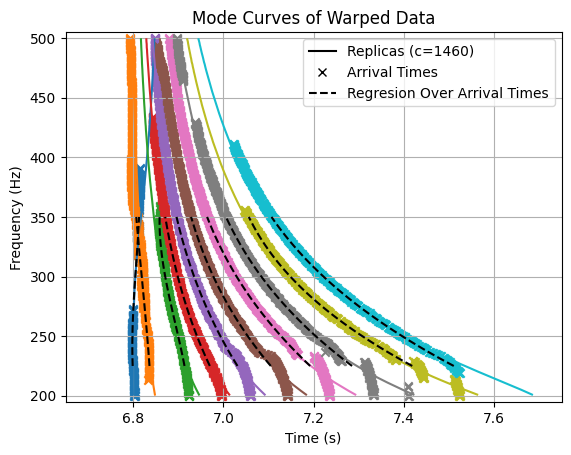

In [170]:
fig, ax = plt.subplots()

for ind, p in enumerate(data1['peaks_coordinates']):
    ll = ax.scatter(p[:,0], p[:,1], marker='x')
    ax.plot(receiver_range/Vg[data1['mode_nos'][ind], c==TRUE_SOUNDSPEED].T, f_Vg)
    
ax.set_prop_cycle(None)
ldash = ax.plot(arrival_times_data.T, regression_f, ls='--', c='k')[0]

ax.set_xlim([6.65, 7.75])
ax.set_ylim([195,505])

ax.grid()

ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Mode Curves of Warped Data")

lsolid = ax.plot(0,0,'k-')[0]
markers = ax.plot(0,0,'kx')[0]

ax.legend([lsolid, markers, ldash], ['Replicas (c=1460)', 'Arrival Times', 'Regresion Over Arrival Times'])

In [171]:
fig.savefig('../data/output/figures/mode_curves_warped.png')

## Likelihood

In [160]:
l1 = ai.AcousticInversionLikelihood(arrival_times_data)

In [161]:
normalize = lambda x: x/np.sum(x)

In [162]:
likelihood = l1.likelihood(arrival_times_replica[:, data1['mode_nos'],:], 1e0)

In [163]:
likelihood = normalize(likelihood)

In [164]:
pmf_mean = lambda x, p: np.sum(x*p)
pmf_var = lambda x, p: pmf_mean(x**2, p) - pmf_mean(x,p)**2

In [165]:
var = pmf_var(c, likelihood)

Text(0.5, 0.98, 'Likelihood on warped data')

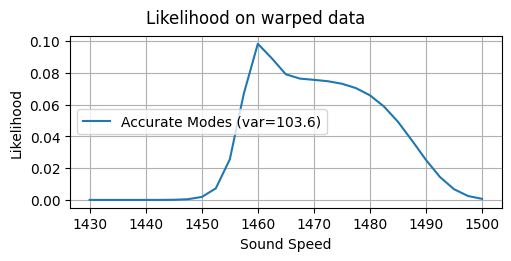

In [166]:
fig, ax = plt.subplots(layout="constrained")

ax.plot(c, likelihood)
ax.grid()

ax.legend([f"Accurate Modes (var={var:1.1f})"])

ax.set_xlabel("Sound Speed")
ax.set_ylabel("Likelihood")

fig.set_size_inches([5, 2.5])
fig.suptitle("Likelihood on warped data")

In [167]:
fig.savefig("../data/output/likelihood_warped.png", dpi=600)